# Spatial Cell ID workshop 

## Introduction 

Kontext is a tool for interpretable spatial domains identification based on kernel methods that has competitive performances, is lightweight and faster than most methods. 
Kontext is not only a spatial domain identification method, the downstream tasks allow one to interpret the spatial domains in terms of cell-cell communication, niche analysis, local alignment, and many others (not implemented yet).  
Kontext is a python package entirely compatible with the scverse ecosystem. It relies on standard machine learning packages such as numpy, pandas, scipy and scikit-learn. Kontext has been developped by Anthony Ozier-Lafontaine, Paul Villoutreix and Laura Cantini, 
in the Machine Learning for Integrative Genomics (ML4IG) team of Pasteur institute led by Laura Cantini. 
The associated preprint and the python package will be available at the end of september 2026. 

## Kontext in a nutshell

### Spatial domains 

Given a spatial transcriptomic dataset of $n$ observations and $G$ genes, Kontext relies on two matrices, the expression matrix $X$ of size $n \times G$ and the local microenvironment matrix $C$ of size $n \times G$. 
The local microenvironment matrix $C$ associated each observation to a vector summarizing the local presence of each gene in the neighboring cells. 
The weights used to compute $C$ are obtained from the product of two kernel functions, $k_s$ to quantify the spatial proximity, and $k_x$ to quantify the expression similarity. $k_s$'s parameter is a number of neighbors to consider `snn`and $k_x$'s parameter is a coeficient for the bandwith size `\sigma_e`.

The third Kontext parameter is the balance parameter $\alpha$ used to obtain the spatial domains embedding :

$$E_i = \alpha X_i + (1-\alpha)C_i$$

### Downstream tasks

The expressions $X$, weights $W$, and microenvironment embeddings $C$ can be leveraged for various analyses that can enhance the interpretability of Kontext spatial domains. In this notebook, we explore several of them. 

- **Cell-cell communication** : Kontext's cell-cell communication scores rely on the idea that a ligand $L$ and receptor $R$ are probably interacting if the receptor transcript is found in the cell ($X_{i,R}>0$) and the ligand transcript is expressed in the cells nearby $(C_{i,L}>0)$. We quantify this with :
$$S_{i,(L,R)} = X_{i,R} \times C_{i,L}. $$
- **Sender-receiver communication** : By reducing the microenvironment embedding to the contribution of a sender group and look at the resulting communication scores in a specific receiver population, we obtain the sender-receiver communication. 
- **Niche analysis** : Which cell types are surrounding each cell ? The niche context contains this information, that can be used for co-localization analysis.
- **Local alignment** : How much a cell is aligned with its local microenvironment ? The local alignment scores quantifies this.  


## Goal of the workshop 

Kontext can be considered as a simple framework able to perform many spatial transcriptomics analyses. 
At the end of the workshop, you should be able to apply Kontext on your own dataset and to know how to access to the main Kontext quantities.



## Presentation of the dataset

We will analyse a Xenium dataset containing 8 sections from 3 time points (sham, 7 days post injury, 28 days post injury) from mouse hearts that are recovering from an injury. You can find the publication associated to this dataset here : https://www.nature.com/articles/s44161-025-00739-6

# 1 - Load data 

In [1]:
import scanpy as sc
adata = sc.read_h5ad('../data/cryoinjury.h5ad')
print(adata)

AnnData object with n_obs × n_vars = 262133 × 540
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'cell_type', 'global_cell_type', 'time', 'main_cell_type', 'sample'
    uns: 'data'
    obsm: 'spatial'
    layers: 'counts'


As you can see, this dataset contains 262133 cells and 540 genes were present in the Xenium panel. 
Informations about the cells are contained in the `adata.obs` dataframe. 
The column `cell_type`contains all the cell type annotations from the original publication, we summarized them into 11 cell types in the column `main_cell_type`. 

The column `time` assings each cell to its time point :
- sham (2 samples): `sham` 
- 7 days post injury (3 samples) : `cryo7D` 
- 28 days post injury (3 samples) : `cryo28D`

The column `sample`assigns each cell to its sample of origin :
- sham : `sham_s1`, `sham_s2``
- 7 days post injury : `cryo7D_S1`, `cryo7D_S2`, `cryo7D_S2`
- 28 days post injury : `cryo28D_S1`, `cryo28D_S2`, `cryo28D_S2`


First, lets explore visually the different samples. 

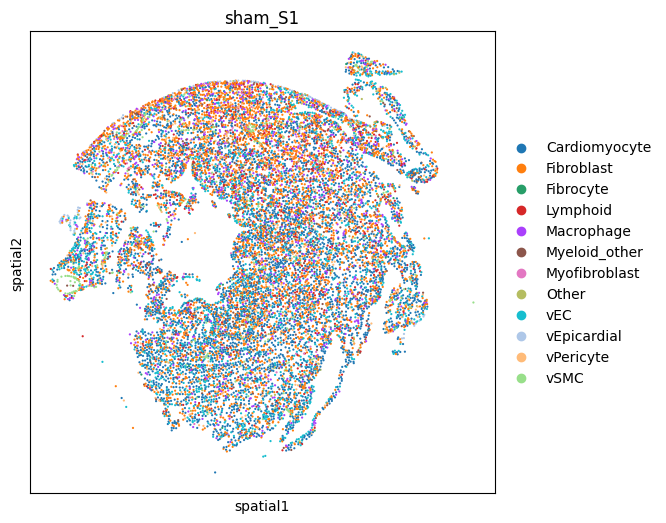

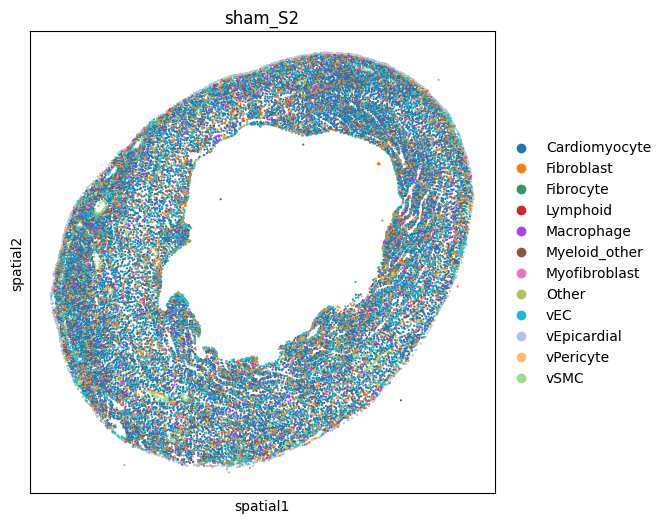

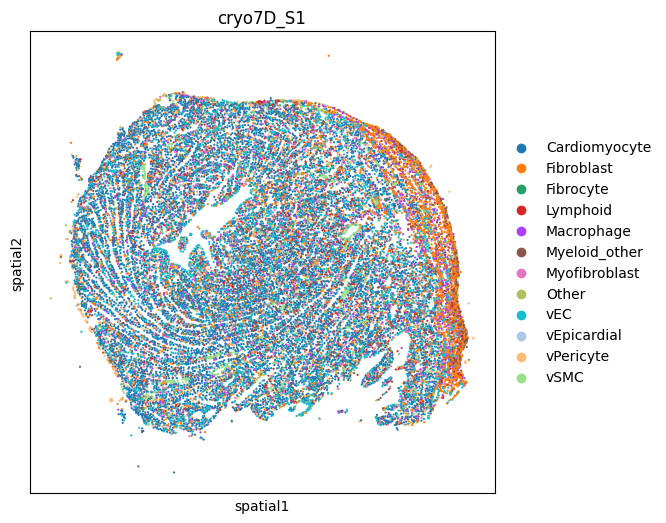

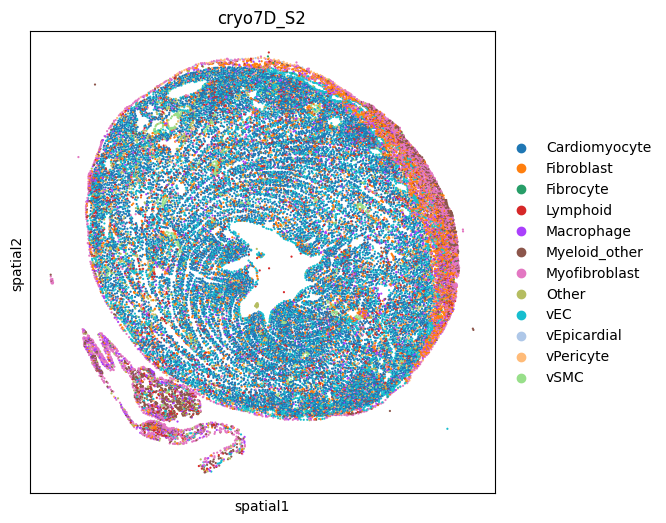

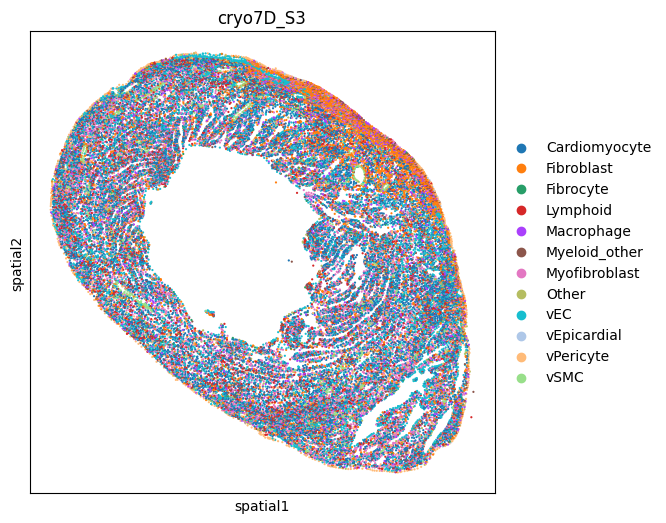

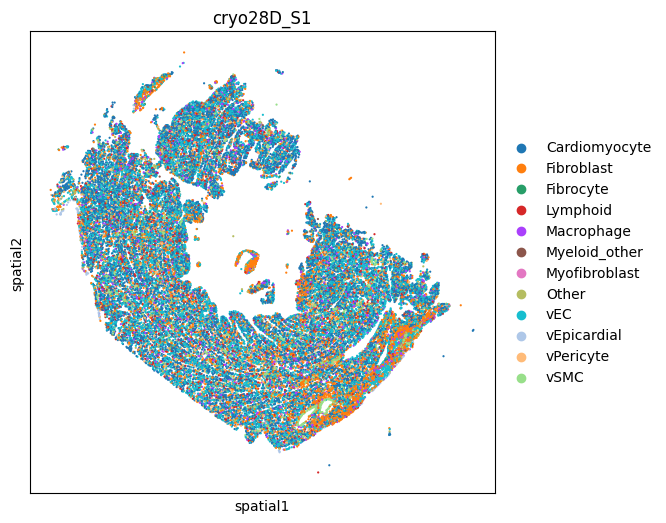

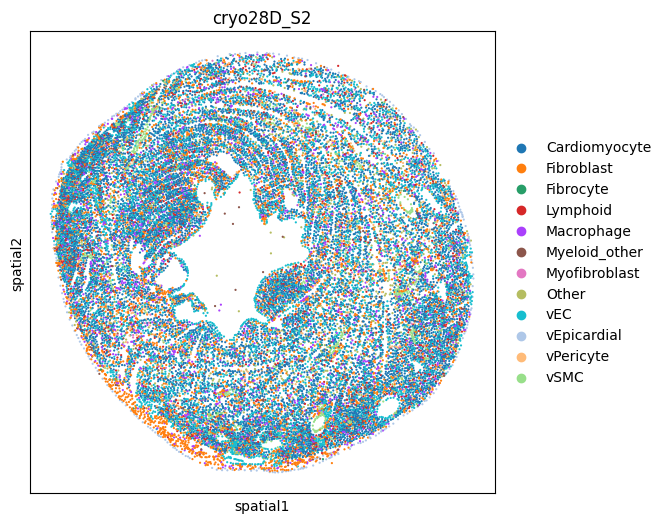

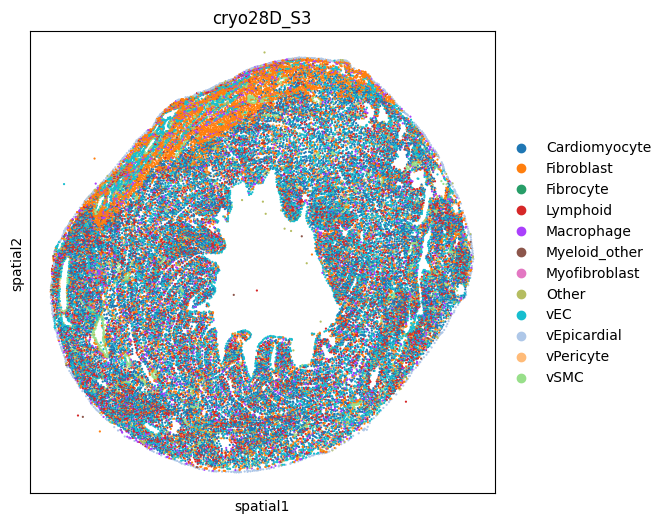

In [2]:
import matplotlib.pyplot as plt
from kontext.visualization import get_figs,space_plot

samples = ['sham_S1','sham_S2',
            'cryo7D_S1','cryo7D_S2','cryo7D_S3',        
            'cryo28D_S1','cryo28D_S2','cryo28D_S3',]

for sample in samples : 
    adata_sample = adata[adata.obs['sample']==sample].copy()

    fig,ax = get_figs(1)
    space_plot(adata_sample,'main_cell_type',ax=ax,s=10)
    ax.set_title(sample)
    plt.show()


# 2 - Kontext spatial domains 

Few steps are necessary to obtain spatial domains with Kontext. 

### Parameters definition 

Lets fix all the parameters once to see them all together. There are 3 groups of parameters to fix : `preprocessing`, `embedding`, `spatial_domains` first one is the preprocessing. 

### Preprocessing

The key design choice behind Kontext efficiency is to always work with sparse data. Based on that, we propose several preprocessing approaches depending on the data. All the proposed methods are applying `log1p` and `L2-normalization` to the data (Kontext normalization). The details are as follow : 

For full transcriptome sequencing-based technologies : 
- `sparse` : Filters genes present in less than 20 cells before Kontext normalization 
- `sparse_hvg` : Filters genes present in less than 20 cells and selects the 2000 most highly variable genes before Kontext normalization. 
- `spase_hvg_LR` : Filters genes present in less than 20 cells and selects the union of the 2000 most highly variable genes and genes that are involved with Ligand-Receptor pairs (only implemented for human data yet) before Kontext normalization. 

For imaging-based technologies such as MERFISH or Xenium : 
- `image` : Applies Kontext normalization directly 

Here, we are working with a Xenium dataset so we use the `image` preprocessing. 

In [3]:
from kontext.data import preprocess_adata

preprocessing = {'preprocessing':'image'}
adata = preprocess_adata(adata,**preprocessing)

### Embedding 

The embedding parameters correspond to the spatial proximity, expression similarity and balance between expression and local microenvironment. They are used to compute weights $W$, microenvironment embeddings $C$ and spatial domains embeddings $E$. 
- `sigma_e` (default: 1): parameter of the expression similarity kernel. 
- `snn`  (default: 20) : number of neighbors to consider around each cell. 
- `alpha`(default: 0.5) : balance between expression $X$ and local microenvironment $C$


**Question :** 

We used the default parameters for this analysis. Choose your parameters and initiate your Kontext object. 

In [4]:
from kontext.kontext_class import Kontext

# To fill : 
# embedding = {"sigma_e":,  
#              "snn":, 
#              'alpha':, 
embedding = {"sigma_e":1,  
             "snn":20, 
             'alpha':0.5, 
              }



# The Kontext object does not contains any data, its purpose it to interact and update the AnnData object.
ko = Kontext(**embedding,verbose=False)

Actually, to ensure that different sections will not interfere with each other, we compute weights on each section separately, then we merge them.  

The function `ko.weights` computes the weights based on spatial proximity and expression similarity. 



In [5]:
from kontext.data import merge_adatas


adatas = {} 
for sample in samples:
    adata_sample = adata[adata.obs['sample']==sample].copy()
    adata_sample.uns = adata.uns.copy()
    adata_sample.uns['data']['sample']=sample


    ko.weights(adata_sample)


    adatas[sample] = adata_sample

adata = merge_adatas(adatas,block_diag_keys=['w','ws','wc','we'])

The spatial domains embeddings will be automatically computed when calling the spatial_domains function, and a computational trick allows to avoid computing the microenvironment embeddings $C$. 
For the sake of completeness, we still compute the microenvironment embeddings $C$ and the spatial domains embeddings $E$. 
- Run `ko.microenvironment_embedding` to compute $C$.
- Run `ko.spatial_domains_embedding` to compute $E$. 

As $C$ and $E$ have the same dimension than $X$, they are stored in `adata.layers`. 

In [6]:
ko.microenvironment_embedding(adata)
ko.spatial_domains_embedding(adata)

print(adata)
print('C : ',adata.layers['C'].shape)
print('E : ',adata.layers['E'].shape)

AnnData object with n_obs × n_vars = 262133 × 540
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'cell_type', 'global_cell_type', 'time', 'main_cell_type', 'sample'
    uns: 'data'
    obsm: 'spatial', 'ws', 'we', 'wc', 'w'
    layers: 'counts', 'C', 'E'
C :  (262133, 540)
E :  (262133, 540)


**Question (not mandatory)** 

As it is always insightful to visually explore a new embedding, we can look at the UMAP plot of these two embeddings. 
Computing the PCA and UMAP can take few minutes. 

 Choose a umber of principal components `n_comps` (default: 50), a layer ($X$, $C$ or $E$), compute the PCA and UMAP, then choose an information to display in the umap space. 

In [ ]:
from umap.umap_ import UMAP 
from kontext.visualization import umap_plot

n_comps = # to fill 


### Uncomment your choice : 

### PCA of the count matrix X 
# layer = 'X'
# pca_of_mat(adata,adata.X,n_comps=n_comps,key=layer)

### PCA of the microenvironment embedding 
# layer = 'C'
# pca_of_mat(adata,adata.layers[layer],n_comps = n_comps)

### PCA of the microenvironment embedding 
# layer = 'E'
# pca_of_mat(adata,adata.layers[layer],n_comps = n_comps)


# UMAP 
adata.obsm[f'{layer}_umap'] = UMAP(n_components=2).fit_transform(adata.obsm[f'{layer}_pca'])


color =  # choose any column present in adata.obs (e.g. time, sample, cell_type, main_cell_type)
fig,ax = get_figs(1)
umap_plot(adata,color,ax=ax,umap_key=f'{layer}_umap')


SyntaxError: invalid syntax (659340351.py, line 26)

### Spatial domains 

Everything is ready to compute the spatial domains. 
This computation relies on a number of domains `n_domains`, a clustering algorithm `clustering` and a random seed `seed`. 
We currently propose the Gaussian mixture model algorithm `gmm` and the Kmeans clustering `kmeans`. Leiden and Louvain will be added later. 

**Question :**

We did our analysis with $8$ spatial domains. Choose your number of domains and compute the spatial domains

In [7]:

# n_domains =  # to fill 
n_domains =  8# to fill 
spatial_domains = {'n_domains':n_domains,'clustering':'gmm','seed':0}
ko.spatial_domains(adata,**spatial_domains)


AnnData object with n_obs × n_vars = 262133 × 540
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'cell_type', 'global_cell_type', 'time', 'main_cell_type', 'sample', 'spatial_domains', 'snn20_se1_nPC50_a0.50_gmm_seed0_n_domains8'
    uns: 'data', 'signature'
    obsm: 'spatial', 'ws', 'we', 'wc', 'w', 'E_pca'
    layers: 'counts', 'C', 'E'

The first thing we want to do is to look at the obtained domains. 
First we plot the superposed samples to overcome a scanpy artifact with colors. 
Then we show each spatial domain in a chosen section. 

**Question :** 

Choose a section and display its spatial domains. 

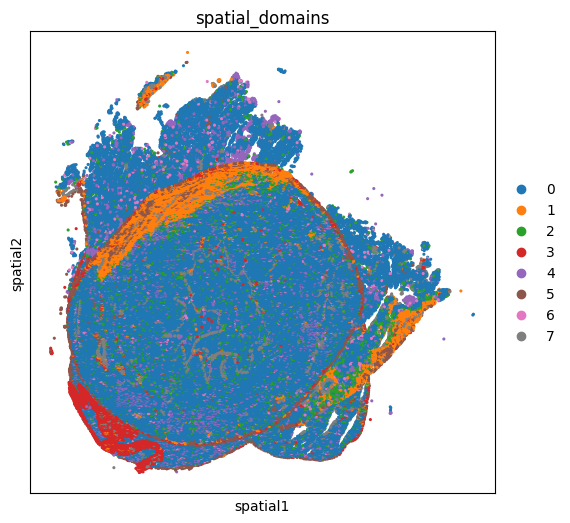

In [11]:
from kontext.visualization import space_plot
# This cell is used to overcome a technical artifact in scanpy 
# that needs to plot the domains to have the same colors across all samples. 
# The resulting plot shows all the samples superposed and is not readable. 
space_plot(adata,'spatial_domains')

# Alternatively, you can simply hard code the spatial domain colors : 
# spatial_domains_colors = [
#     "#0072B2","#D55E00","#009E73","#CC79A7",
#     "#E69F00","#56B4E9","#F0E442","#4E1A1A",]
# adata.uns['spatial_domains_colors'] = spatial_domains_colors


# Same artifact for the cell types, we hardcode the main_cell_type colors. 
cell_type_colors = [
    "#8DD3C7","#FFFFB3","#BEBADA","#FB8072",
    "#80B1D3","#FDB462","#B3DE69","#FCCDE5",
    "#D9D9D9","#BC80BD","#CCEBC5", "#FFED6F",
    "#DCD685","#D7AFAF",]
adata.uns['main_cell_type_colors'] = cell_type_colors

The function `space_plot_mask` allows to focus on the cells corresponding to the value `group`in the column `col`. The other cells are shown in grey. You can display any information about the group of interest with the parameter `color`. 

**Question :** 

Choose a sample to display and look at your spatial domains. 

/pasteur/helix/projects/ml4ig_hot/Users/aozierla/kontext_project/.venv/lib/python3.12/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
/pasteur/helix/projects/ml4ig_hot/Users/aozierla/kontext_project/.venv/lib/python3.12/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
/pasteur/helix/projects/ml4ig_hot/Users/aozierla/kontext_project/.venv/lib/python3.12/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
/pasteur/helix/projects/ml4ig_hot/Users/aozierla/kontext_project/.venv/lib/python3.12/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
/pasteur/helix/projects/ml4ig_hot/Users/aozierla/kontext_project/.ve

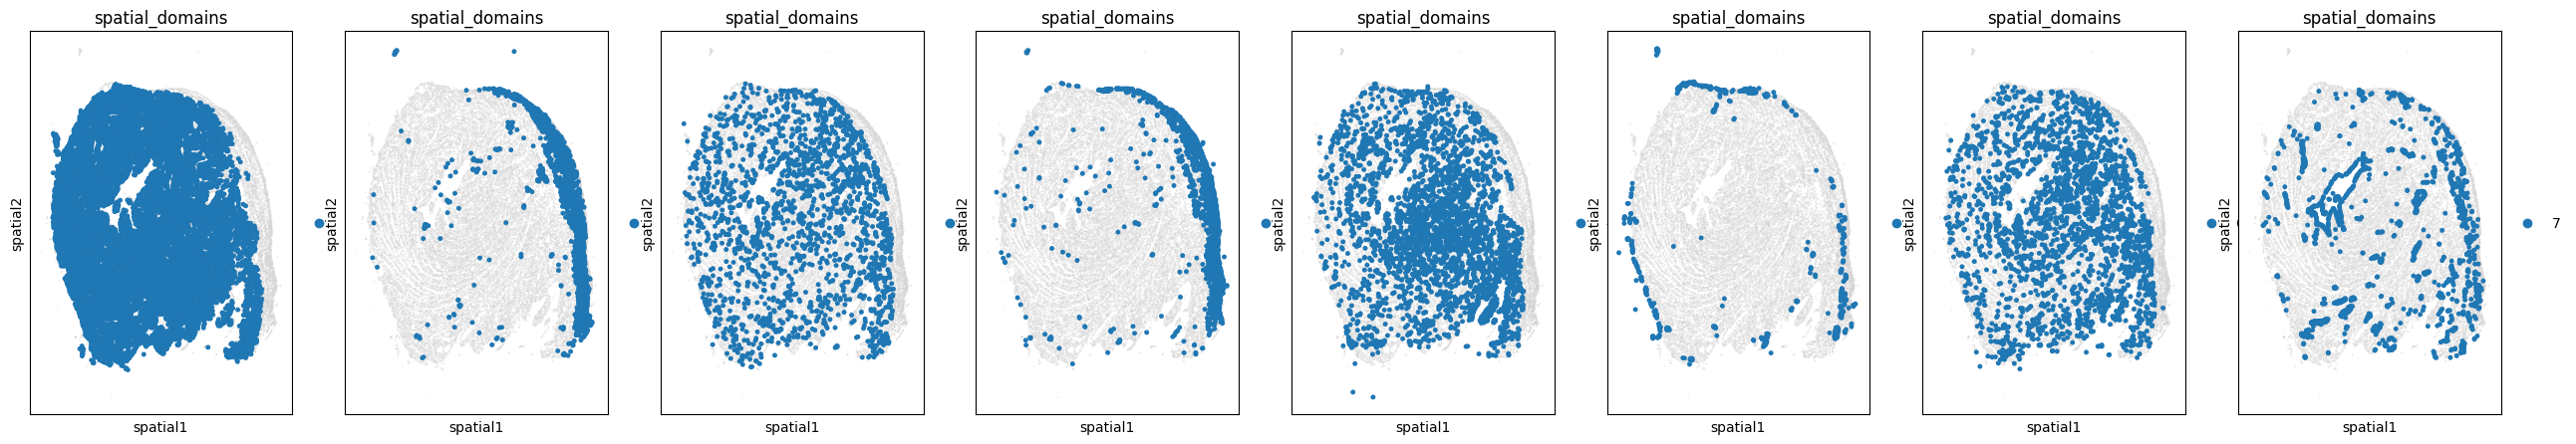

In [8]:

from kontext.visualization import space_plot_mask

samples = ['sham_S1','sham_S2',
            'cryo7D_S1','cryo7D_S2','cryo7D_S3',        
            'cryo28D_S1','cryo28D_S2','cryo28D_S3',]

# sample= # to fill, pick one in samples
sample='cryo7D_S1' # to fill, pick one in samples
adata_k = adata[adata.obs['sample']==sample].copy()

fig,axes = get_figs(n_domains,4,5)
for ax,domain in zip(axes,range(n_domains)):
    mask = space_plot_mask(adata_k,
                           col='spatial_domains',
                           group=domain,
                            # color = 'main_cell_type',
                           ax=ax,snm=5,sm=50)


In addition to the visual aspect of the spatial domain, it is interesting to describe their cell type composition. The function `get_proportions` simply computes a table that displays the proportions of categories of `col2` in each category of `col1`. Here we use it to display the `main_cell_type` proportions in each spatial domain in `spatial_domains`. 

KeyError: 'main_cell_type_colors'

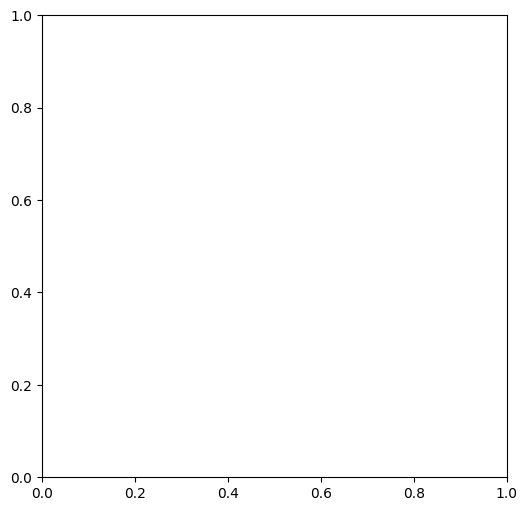

In [9]:
from kontext.visualization import get_proportions, plot_region_distribution
col1 = 'spatial_domains'
col2 = 'main_cell_type'
proportions = get_proportions(adata,col1,col2,normalize=False)

fig,ax = get_figs(1)
plot_region_distribution(proportions,colors = adata.uns[f'{col2}_colors'] ,ax=ax,fontsize=12,format_value='.2f',threshold=.1,percentage=True)


# 3 - Downstream tasks 

## 3.1 - Cell-cell communication 

We now interpret the spatial domains in terms of ligand-receptor interactions. 
To do so, we start with `get_LR_pairs` to identify the ligand-receptor pairs present in the dataset for this organism (`mouse`) using the Liana database (https://www.nature.com/articles/s41556-024-01469-w).  

**Question :** 

Explore the LR pairs available in this Xenium panel, you might know some of them. 

In [ ]:
from kontext.utils import get_LR_pairs

pairs = get_LR_pairs(adata, organism='mouse', verbose=False)
print(pairs)



                ligand receptor             LR
LR                                            
Col2a1_Cd44     Col2a1     Cd44    Col2a1_Cd44
Col2a1_Sdc1     Col2a1     Sdc1    Col2a1_Sdc1
Thbs4_Cd36       Thbs4     Cd36     Thbs4_Cd36
Thbs4_Sdc1       Thbs4     Sdc1     Thbs4_Sdc1
Comp_Cd36         Comp     Cd36      Comp_Cd36
Comp_Sdc1         Comp     Sdc1      Comp_Sdc1
Angpt2_Tie1     Angpt2     Tie1    Angpt2_Tie1
Hp_Asgr1            Hp    Asgr1       Hp_Asgr1
Hp_Itgam            Hp    Itgam       Hp_Itgam
Apoc2_Lrp2       Apoc2     Lrp2     Apoc2_Lrp2
Gc_Lrp2             Gc     Lrp2        Gc_Lrp2
Spp1_Cd44         Spp1     Cd44      Spp1_Cd44
Ccl12_Ccr2       Ccl12     Ccr2     Ccl12_Ccr2
Cxcl2_Cxcr2      Cxcl2    Cxcr2    Cxcl2_Cxcr2
Ptn_Sdc1           Ptn     Sdc1       Ptn_Sdc1
S100a4_Erbb2    S100a4    Erbb2   S100a4_Erbb2
Wnt5a_Lrp2       Wnt5a     Lrp2     Wnt5a_Lrp2
Xcl1_Xcr1         Xcl1     Xcr1      Xcl1_Xcr1
Ccl12_Ackr2      Ccl12    Ackr2    Ccl12_Ackr2
C3_C3ar1     

For the analysis, we focused on some specific pairs of interest.

In [ ]:
pairs_of_interest = [
    'Cfh_Itgam','C3_Itgam','C3_C3ar1',
    'Ccl12_Ccr2','Spp1_Cd44','Mmp9_Cd44','Ptn_Sdc1',
    'Thbs4_Cd36','Thbs4_Sdc1','Comp_Sdc1',
    'Bmp7_Eng',
    'Timp3_Cd44','S100a4_Erbb2',
    'Timp3_Kdr','Angpt2_Tie1',]

Now we compute the cells communication scores with `cell_cell_communication` ( defined as the mean of the scores averaged across all LR pairs), cell scores are stored in `adata.obs['cell_communication']`. 

The function `plot_ccc_score_per_group` allows to visually see the average score across each category of `group_col` (here `spatial_domains`). For interpretation, this function displays the space plot of a sample (`column_shown`,`sample_shown`). 

/pasteur/helix/projects/ml4ig_hot/Users/aozierla/kontext/src/kontext/visualization.py:299: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


<Axes: xlabel='Group', ylabel='CCC score (mean)'>

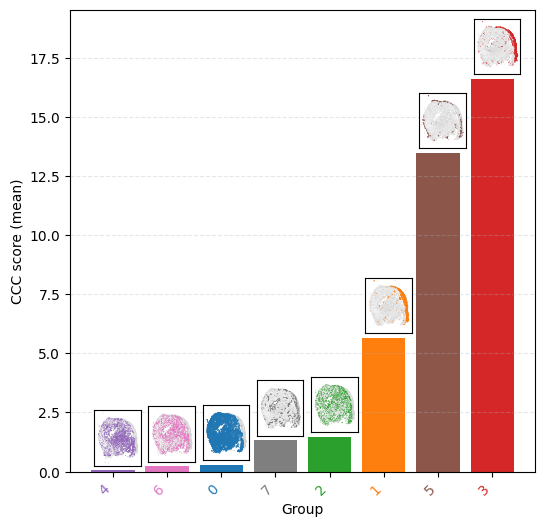

In [ ]:
from kontext.visualization import plot_ccc_score_per_group

fig,ax = get_figs(1)
ko.cell_cell_communication(adata,pairs,mode='mean')

plot_ccc_score_per_group(adata,
                         group_col = 'spatial_domains',
                         ccc_score_col = 'cell_communication',
                         column_shown ='sample',
                         sample_shown='cryo7D_S1', 
                         ax=ax, insersion=(.10, .12))

### 3.2 - Sender-receiver communication 

Now we look at the sender-receiver communication scores between two cell populations. 

**Question :**

In our work, we focused on the communication of Fibroblasts and Macrophages over time. 
Choose two cell populations and display their communication over time then over spatial domains. 

In [10]:
import seaborn as sns

groups = 'main_cell_type'
t1, t2 = 'Fibroblast', 'Macrophage'
times = 'sham','cryo7D','cryo28D'


for receiver,sender in (t1, t2),(t2,t1),(t1, t1), (t2, t2): 
    ko.init_sender_receiver_communication(adata,pairs,sender,receiver,groups)

for receiver,sender in (t1, t2),(t2,t1),(t1, t1), (t2, t2): 
    T = ko.sender_receiver_scores(adata,pairs,sender,receiver,groups,receiver_threshold=0.1,group_by='time',by_order=times)
    T = T[pairs_of_interest]


    fig,ax = get_figs(1)
    hm = sns.heatmap(T.T, ax=ax, cmap='RdBu_r', center=0, vmin=-6, vmax=4,
                annot=True, fmt='.2f', annot_kws={'fontsize':15},
                linewidths=.5,) #cbar=cbar, cbar_kws={'label': label})
    ax.set_title(f'{sender} to {receiver}')

NameError: name 'pairs' is not defined

Note that the compared groups should be encoded within the same `adata.obs` column. 
Thus if one wants to focus on the communication between two specific groups, such as macrophages in spatial domain 1 with fibroblasts in spatial domain 1, you will need to create a custom `obs` column. 

**Question (not mandatory)** 

Choose two specific groups you want to compare, construct the custom column and display the resulting scores.  

In [19]:
import pandas as pd 

# example of a custom column 
adata.obs[f'type_domain'] = pd.Categorical(adata.obs['main_cell_type'].astype(str) + '_' + adata.obs[f'spatial_domains'].astype(str))

# To fill 
# 
# 

### 3.3 Niche analysis. 

Given a group `cell_type_key` (e.g. `'spatial_domains'`), the niche context vector of a cell quantifies the presence of each category of the group in its local microenvironment. 

The function `ko.niche`computes the niche matrix with respect to `cell_type_key` and stores it in `adata.obsm[f'niche_{cell_type_key}']` and each column is stored in `adata.obs[f'niche_{cell_type_key}_{}']

**Question :** 

Compute a niche matrix and explore it. 

niche_spatial_domains_0    35174.613416
niche_spatial_domains_0    35174.613416
niche_spatial_domains_0    35174.613416
niche_spatial_domains_0    35174.613416
niche_spatial_domains_0    35174.613416
niche_spatial_domains_0    35174.613416
niche_spatial_domains_0    35174.613416
niche_spatial_domains_0    35174.613416
niche_spatial_domains_0    35174.613416
niche_spatial_domains_0    35174.613416
niche_spatial_domains_0    35174.613416
niche_spatial_domains_0    35174.613416
dtype: float64
sham_S1


AttributeError: 'DataFrame' object has no attribute 'dtype'

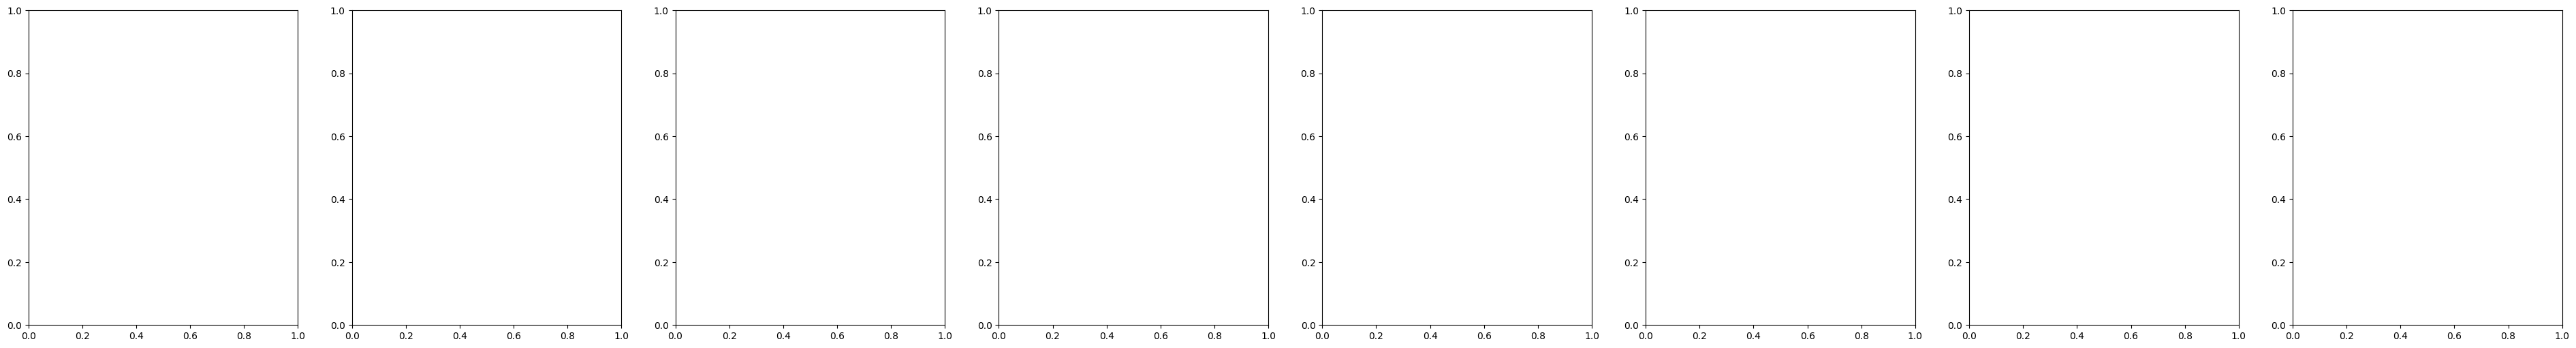

In [22]:
cell_type_key = 'spatial_domains' # to fill
ko.niche(adata, cell_type_key=cell_type_key)


# space plot one information 
category = 0# to fill
print(adata.obs[f'niche_{cell_type_key}_{category}'].sum() )
print(sample)
# adata_sample = adata[adata.obs['sample']==sample].copy()

adata.obs['sample']= adata.obs['sample'].astype('category')
fig,axes = get_figs(len(samples))
for sample,ax in zip(samples,axes) :

    adata_sample = adata[adata.obs['sample']==sample]
    # space_plot(adata_sample,f'niche_{cell_type_key}_{category}',ax=ax)


In [ ]:

import numpy as np
import pandas as pd
# Heatmap the values 
def niche_enrichment(adata, group,categories_of_interest,
                     key="niche_annotation", categories=None):
    """Log2 enrichment of niche context in clusters vs global baseline."""
    N = adata.obsm[key].toarray() if sps.issparse(adata.obsm[key]) else np.asarray(adata.obsm[key])
    categories = categories or adata.uns[key]["categories"]
    global_mean = N.mean(axis=0)  # expected
    print(global_mean)
    idx = np.where(adata.obs[group].isin(categories_of_interest))[0]
    cluster_mean = N[idx].mean(axis=0)  # observed
    print(cluster_mean)
    enrichment = np.log2((cluster_mean + 1e-9) / (global_mean + 1e-9))
    return pd.Series(enrichment, index=categories)
niche_enrichment(adata,'main_cell_type',['Fibroblast','Macrophage'],key = 'niche_spatial_domains')


In [ ]:
pd.DataFrame(adata.obsm['niche_spatial_domains'],index = adata.obs_names,columns = )

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 554248 stored elements and shape (262133, 8)>

In [ ]:
# Description of spatial alignment 

In [ ]:
me_correlation(adata_k, layer_C="C")

In [ ]:
# Final exercice : open questions, become a computational biologist yourself 

# Compute the correlation between expression and microenvironment presence of genes 
# to measure spatial coexpression of genes. 